# Bill Management Agent
A multi-agent system using AutoGen Group Chat for processing bills and summarizing expenses.

In [1]:
!pip install autogen groq pillow requests -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.9 MB/s eta 0:00:00


In [2]:
import os
import base64
import json
from groq import Groq

# Get GROQ API key from Colab secrets
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except Exception:
    GROQ_API_KEY = os.environ.get('GROQ_API_KEY', 'your-groq-api-key-here')

print("GROQ API Key loaded:", "Yes" if GROQ_API_KEY else "No - Please set your key")

GROQ API Key loaded: Yes


In [3]:
# Initialize GROQ client
client = Groq(api_key=GROQ_API_KEY)

def encode_image_to_base64(image_path: str) -> str:
    """Encode an image file to base64 string."""
    with open(image_path, 'rb') as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def get_image_media_type(image_path: str) -> str:
    """Determine the media type based on file extension."""
    ext = image_path.lower().split('.')[-1]
    media_types = {
        'jpg': 'image/jpeg',
        'jpeg': 'image/jpeg',
        'png': 'image/png',
        'gif': 'image/gif',
        'webp': 'image/webp'
    }
    return media_types.get(ext, 'image/jpeg')

print("Utility functions defined successfully.")

Utility functions defined successfully.


In [4]:
# ─────────────────────────────────────────────
# Agent Definitions
# ─────────────────────────────────────────────

class Agent:
    """Base agent class."""
    def __init__(self, name: str, role: str, system_prompt: str):
        self.name = name
        self.role = role
        self.system_prompt = system_prompt

    def respond(self, message: str, image_path: str = None) -> str:
        raise NotImplementedError


class UserProxyAgent(Agent):
    """Initiates conversation with the Group Manager by sharing bill images."""

    def __init__(self):
        super().__init__(
            name="UserProxy",
            role="User Representative",
            system_prompt="You are a user proxy that initiates the bill processing workflow."
        )

    def initiate(self, image_path: str) -> dict:
        """Initiate a message to the group with the bill image."""
        message = (
            f"Hello Group Manager, I have uploaded a bill image at '{image_path}'. "
            "Please coordinate with the Bill Processing Agent to extract and categorize "
            "all expenses from this bill, and then have the Expense Summarization Agent "
            "provide spending insights."
        )
        return {"sender": self.name, "message": message, "image_path": image_path}


class BillProcessingAgent(Agent):
    """Extracts and categorizes expenses from bill images using GROQ vision."""

    CATEGORIES = ["Groceries", "Dining", "Utilities", "Shopping", "Entertainment", "Healthcare", "Travel", "Other"]

    def __init__(self, groq_client: Groq):
        super().__init__(
            name="BillProcessingAgent",
            role="Bill Processor",
            system_prompt=(
                "You are a bill processing expert. Analyze bill/receipt images and extract "
                "all line items with their costs. Categorize each item into one of: "
                "Groceries, Dining, Utilities, Shopping, Entertainment, Healthcare, Travel, or Other. "
                "Return your response as a valid JSON object with this structure: "
                '{"store_name": "...", "date": "...", "items": [{"name": "...", "category": "...", "amount": 0.00}], "total": 0.00}'
            )
        )
        self.client = groq_client

    def process_bill(self, image_path: str) -> dict:
        """Extract and categorize expenses from a bill image."""
        print(f"\n[{self.name}] Processing bill image: {image_path}")

        try:
            image_data = encode_image_to_base64(image_path)
            media_type = get_image_media_type(image_path)

            response = self.client.chat.completions.create(
                model="meta-llama/llama-4-scout-17b-16e-instruct",
                messages=[
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "image_url",
                                "image_url": {
                                    "url": f"data:{media_type};base64,{image_data}"
                                }
                            },
                            {
                                "type": "text",
                                "text": (
                                    "Analyze this bill/receipt image. Extract ALL line items with their costs. "
                                    "Categorize each into: Groceries, Dining, Utilities, Shopping, Entertainment, "
                                    "Healthcare, Travel, or Other. "
                                    "Return ONLY a valid JSON object (no markdown, no extra text) with this exact structure: "
                                    '{"store_name": "store name", "date": "date if visible", '
                                    '"items": [{"name": "item name", "category": "Category", "amount": 0.00}], '
                                    '"total": 0.00}'
                                )
                            }
                        ]
                    }
                ],
                max_tokens=2048,
                temperature=0.1
            )

            raw_text = response.choices[0].message.content.strip()

            # Clean up markdown code blocks if present
            if raw_text.startswith("```"):
                raw_text = raw_text.split("```")[1]
                if raw_text.startswith("json"):
                    raw_text = raw_text[4:]
            raw_text = raw_text.strip()

            extracted_data = json.loads(raw_text)
            print(f"[{self.name}] Successfully extracted {len(extracted_data.get('items', []))} items.")
            return {"status": "success", "data": extracted_data, "raw_response": raw_text}

        except json.JSONDecodeError as e:
            print(f"[{self.name}] JSON parsing error: {e}. Using raw text.")
            return {"status": "partial", "data": None, "raw_response": raw_text}
        except Exception as e:
            print(f"[{self.name}] Error processing image: {e}")
            return {"status": "error", "data": None, "raw_response": str(e)}


class ExpenseSummarizationAgent(Agent):
    """Analyzes categorized expenses and provides spending insights."""

    def __init__(self, groq_client: Groq):
        super().__init__(
            name="ExpenseSummarizationAgent",
            role="Expense Analyst",
            system_prompt=(
                "You are an expert financial analyst specializing in personal expense management. "
                "Analyze categorized expense data and provide clear, actionable spending insights."
            )
        )
        self.client = groq_client

    def summarize(self, processed_data: dict) -> str:
        """Generate a spending summary and insights from processed bill data."""
        print(f"\n[{self.name}] Generating expense summary and insights...")

        if processed_data["status"] == "error":
            return "Unable to generate summary due to bill processing error."

        data_str = json.dumps(processed_data.get("data") or processed_data.get("raw_response"), indent=2)

        prompt = f"""
Analyze the following extracted bill data and provide a comprehensive expense summary:

{data_str}

Please provide:
1. **Total Expenditure**: Overall total spent
2. **Category Breakdown**: Total amount spent per category with percentage of total
3. **Highest Spending Category**: Which category had the most spending and why it might be notable
4. **Item Count per Category**: Number of items in each category
5. **Spending Insights**: Any unusual patterns, high-value items, or actionable recommendations
6. **Summary**: A concise 2-3 sentence overall assessment of the spending

Format the output in a clear, readable manner with proper sections.
"""

        response = self.client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": self.system_prompt},
                {"role": "user", "content": prompt}
            ],
            max_tokens=1024,
            temperature=0.3
        )

        summary = response.choices[0].message.content
        print(f"[{self.name}] Summary generated successfully.")
        return summary


print("All agent classes defined successfully.")

All agent classes defined successfully.


In [5]:
# ─────────────────────────────────────────────
# Group Chat Manager
# ─────────────────────────────────────────────

class GroupChatManager:
    """Manages the group chat workflow between agents."""

    def __init__(self, groq_client: Groq):
        self.client = groq_client
        self.user_proxy = UserProxyAgent()
        self.bill_processor = BillProcessingAgent(groq_client)
        self.expense_summarizer = ExpenseSummarizationAgent(groq_client)
        self.conversation_history = []
        print("GroupChatManager initialized with all agents.")
        print(f"  • {self.user_proxy.name}: {self.user_proxy.role}")
        print(f"  • {self.bill_processor.name}: {self.bill_processor.role}")
        print(f"  • {self.expense_summarizer.name}: {self.expense_summarizer.role}")

    def _log(self, sender: str, message: str):
        """Log a message to conversation history."""
        entry = {"sender": sender, "message": message}
        self.conversation_history.append(entry)
        print(f"\n{'='*60}")
        print(f"[{sender}]")
        print('='*60)
        print(message)

    def run(self, image_path: str) -> dict:
        """Execute the full bill management workflow."""
        print("\n" + "#"*60)
        print("# BILL MANAGEMENT AGENT - GROUP CHAT STARTED")
        print("#"*60)

        # Step 1: UserProxy initiates
        initiation = self.user_proxy.initiate(image_path)
        self._log(self.user_proxy.name, initiation["message"])

        # Step 2: Group Manager acknowledges and routes to BillProcessingAgent
        manager_msg = (
            f"Received bill image from UserProxy. "
            f"Routing to {self.bill_processor.name} for extraction and categorization."
        )
        self._log("GroupChatManager", manager_msg)

        # Step 3: BillProcessingAgent processes the image
        processed_result = self.bill_processor.process_bill(image_path)

        if processed_result["status"] == "success" and processed_result["data"]:
            bill_data = processed_result["data"]
            items_summary = "\n".join(
                f"  - {item['name']} ({item['category']}): ${item['amount']:.2f}"
                for item in bill_data.get("items", [])
            )
            bill_agent_msg = (
                f"Bill processed successfully!\n"
                f"Store: {bill_data.get('store_name', 'N/A')}\n"
                f"Date: {bill_data.get('date', 'N/A')}\n"
                f"Extracted Items:\n{items_summary}\n"
                f"Total: ${bill_data.get('total', 0):.2f}"
            )
        else:
            bill_agent_msg = (
                f"Bill processing completed with status: {processed_result['status']}.\n"
                f"Raw output:\n{processed_result.get('raw_response', 'No data')}"
            )

        self._log(self.bill_processor.name, bill_agent_msg)

        # Step 4: Group Manager routes to ExpenseSummarizationAgent
        manager_msg2 = (
            f"Categorized expense data received from {self.bill_processor.name}. "
            f"Routing to {self.expense_summarizer.name} for analysis and insights."
        )
        self._log("GroupChatManager", manager_msg2)

        # Step 5: ExpenseSummarizationAgent provides insights
        summary = self.expense_summarizer.summarize(processed_result)
        self._log(self.expense_summarizer.name, summary)

        # Step 6: Final wrap-up
        final_msg = "Workflow complete. Bill has been processed, categorized, and analyzed."
        self._log("GroupChatManager", final_msg)

        print("\n" + "#"*60)
        print("# GROUP CHAT ENDED")
        print("#"*60)

        return {
            "conversation_history": self.conversation_history,
            "processed_data": processed_result,
            "summary": summary
        }


print("GroupChatManager class defined successfully.")

GroupChatManager class defined successfully.


Please upload your bill image (JPG, JPEG, PNG):


Saving sam_bill.jpeg to sam_bill (2).jpeg

Image received: sam_bill (2).jpeg


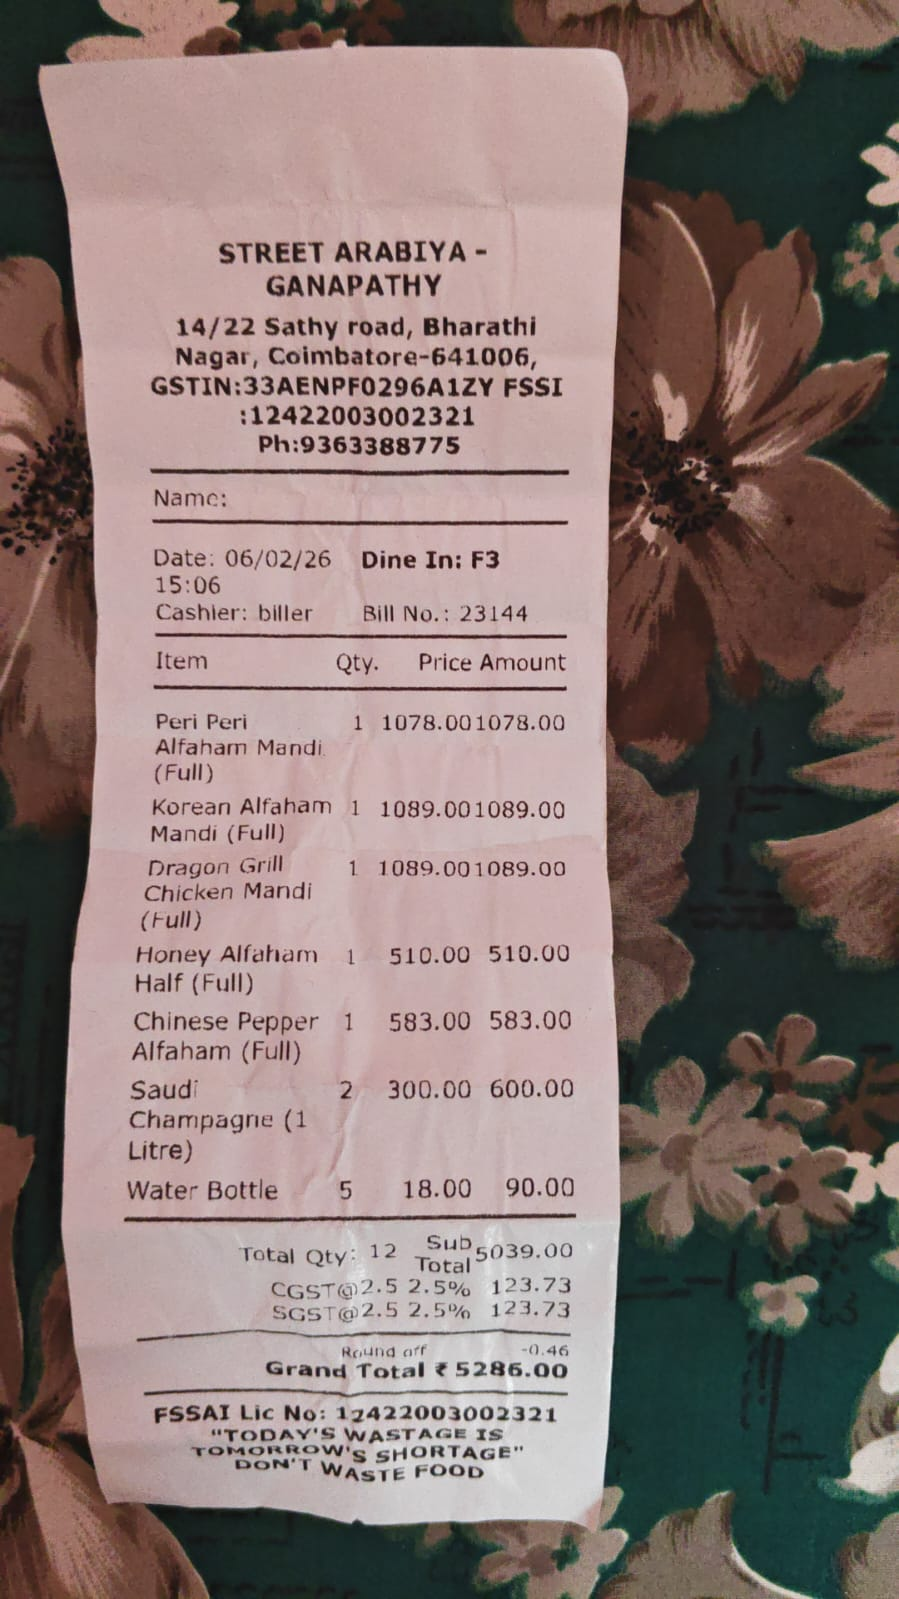

GroupChatManager initialized with all agents.
  • UserProxy: User Representative
  • BillProcessingAgent: Bill Processor
  • ExpenseSummarizationAgent: Expense Analyst

############################################################
# BILL MANAGEMENT AGENT - GROUP CHAT STARTED
############################################################

[UserProxy]
Hello Group Manager, I have uploaded a bill image at 'sam_bill (2).jpeg'. Please coordinate with the Bill Processing Agent to extract and categorize all expenses from this bill, and then have the Expense Summarization Agent provide spending insights.

[GroupChatManager]
Received bill image from UserProxy. Routing to BillProcessingAgent for extraction and categorization.

[BillProcessingAgent] Processing bill image: sam_bill (2).jpeg
[BillProcessingAgent] Successfully extracted 7 items.

[BillProcessingAgent]
Bill processed successfully!
Store: STREET ARABIYA - GANAPATHY
Date: 06/02/26
Extracted Items:
  - Peri Peri Alfaham Mandi (Full) (Dining

In [13]:
# ─────────────────────────────────────────────
# UPLOAD YOUR REAL BILL IMAGE
# ─────────────────────────────────────────────

from google.colab import files
from IPython.display import display, Image as IPImage

print("Please upload your bill image (JPG, JPEG, PNG):")
uploaded = files.upload()

if not uploaded:
    raise ValueError("No file uploaded. Please upload a bill image to proceed.")

IMAGE_PATH = list(uploaded.keys())[0]
print(f"\nImage received: {IMAGE_PATH}")
display(IPImage(filename=IMAGE_PATH))

# Initialize the Group Chat Manager
manager = GroupChatManager(groq_client=client)

# Run the bill management workflow with your real bill
results = manager.run(IMAGE_PATH)

In [14]:
# ─────────────────────────────────────────────
# DISPLAY FINAL STRUCTURED RESULTS
# ─────────────────────────────────────────────

print("\n" + "="*60)
print("FINAL EXPENSE SUMMARY")
print("="*60)
print(results["summary"])

# Display extracted data if available
if results["processed_data"]["status"] == "success" and results["processed_data"]["data"]:
    data = results["processed_data"]["data"]
    print("\n" + "="*60)
    print("CATEGORY BREAKDOWN (Extracted Items)")
    print("="*60)

    # Group by category
    categories = {}
    for item in data.get("items", []):
        cat = item.get("category", "Other")
        if cat not in categories:
            categories[cat] = []
        categories[cat].append(item)

    for cat, items in sorted(categories.items()):
        cat_total = sum(i.get("amount", 0) for i in items)
        print(f"\n📂 {cat} (${cat_total:.2f})")
        for item in items:
            print(f"   • {item.get('name', 'Unknown')}: ${item.get('amount', 0):.2f}")

    print(f"\n{'='*60}")
    print(f"GRAND TOTAL: ${data.get('total', 0):.2f}")
    print("="*60)


FINAL EXPENSE SUMMARY
## Expense Summary
### 1. Total Expenditure
The total expenditure for the given bill data is **5286.0**.

### 2. Category Breakdown
The total amount spent per category, along with the percentage of the total expenditure, is as follows:
- **Dining**: 5286.0 (100%)

Since all items fall under the "Dining" category, it encompasses the entire expenditure.

### 3. Highest Spending Category
The **Dining** category had the most spending, which is notable because it accounts for the entirety of the expenditure, indicating that the bill was solely for dining purposes. The high spending in this category might be due to ordering multiple full-course meals and beverages.

### 4. Item Count per Category
- **Dining**: 7 items

### 5. Spending Insights
- The average cost per item in the Dining category is approximately 754.57, indicating that the meals ordered were of high value.
- The most expensive items were the "Peri Peri Alfaham Mandi (Full)", "Korean Alfaham Mandi (Full)"

In [15]:
# ─────────────────────────────────────────────
# CONVERSATION HISTORY
# ─────────────────────────────────────────────

print("\n" + "="*60)
print("FULL CONVERSATION HISTORY")
print("="*60)
for i, entry in enumerate(results["conversation_history"], 1):
    print(f"\n[Turn {i}] {entry['sender']}")
    print("-" * 40)
    # Truncate long messages for readability
    msg = entry['message']
    if len(msg) > 500:
        msg = msg[:500] + "... [truncated]"
    print(msg)


FULL CONVERSATION HISTORY

[Turn 1] UserProxy
----------------------------------------
Hello Group Manager, I have uploaded a bill image at 'sam_bill (2).jpeg'. Please coordinate with the Bill Processing Agent to extract and categorize all expenses from this bill, and then have the Expense Summarization Agent provide spending insights.

[Turn 2] GroupChatManager
----------------------------------------
Received bill image from UserProxy. Routing to BillProcessingAgent for extraction and categorization.

[Turn 3] BillProcessingAgent
----------------------------------------
Bill processed successfully!
Store: STREET ARABIYA - GANAPATHY
Date: 06/02/26
Extracted Items:
  - Peri Peri Alfaham Mandi (Full) (Dining): $1078.00
  - Korean Alfaham Mandi (Full) (Dining): $1089.00
  - Dragon Grill Chicken Mandi (Full) (Dining): $1089.00
  - Honey Alfaham Half (Full) (Dining): $510.00
  - Chinese Pepper Alfaham (Full) (Dining): $583.00
  - Saudi Champagne (1 Litre) (Dining): $600.00
  - Water Bottl